In [1]:
import re
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import itertools

import meshpy.triangle as tri
from matplotlib.tri import Triangulation

from sango import Network, NodeGroup, EdgeGroup, NodePort, NodeList
from sango.model import LIF, pLIF, PSP

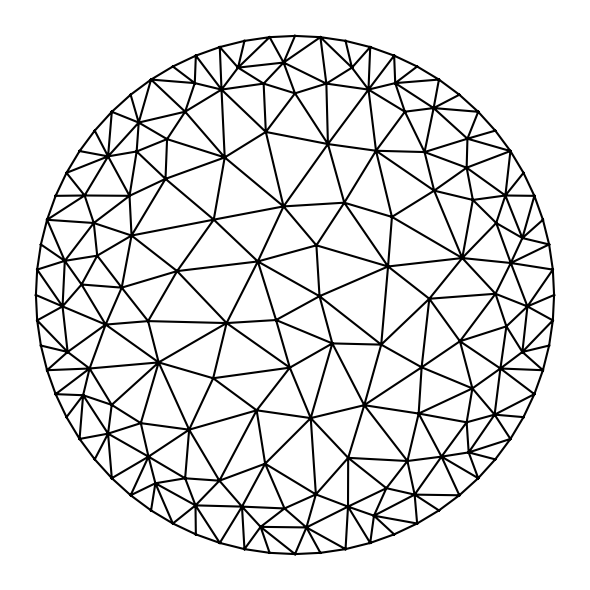

In [2]:
# Build a triangulated mesh on a disk for a system with fixed boundary conditions
# For more detailed parameterization, please refer to https://github.com/sandialabs/NeuroFEM
max_V = 0.04 # max volume
n_bdry = 64 # number of boundary points

# Get boundary points (first set of points in mesh)
bdry_pts = []
bdry_fcs = []
bdry_idxs = np.linspace(0, 2*np.pi, n_bdry, endpoint=False)
bdry_pts.extend([(np.cos(x), np.sin(x)) for x in bdry_idxs])
bdry_fcs.extend([sorted([x, ((x+1) % (n_bdry))]) for x in range(n_bdry)])

# Build mesh
mesh_info = tri.MeshInfo()
mesh_info.set_points(bdry_pts)
mesh_info.set_facets(bdry_fcs)
mesh = tri.build(mesh_info, verbose=False, min_angle=30,
                 volume_constraints=True, max_volume=max_V,
                 allow_boundary_steiner=False)

# Triangulation information in matplotlib for plotting
ts = Triangulation([x[0] for x in mesh.points], [x[1] for x in mesh.points], mesh.elements)

# Plot the mesh
plt.figure(figsize=(6, 6))
plt.triplot(ts, color='k')
plt.axis('off')
plt.tight_layout()

In [3]:
# A population of neurons for a mesh point
# it expects an even number of points
class MeshPoint(Network):
    def __init__(self, num_neuron=8):
        super().__init__()
        self.num_neuron = num_neuron
        self.half_neuron = num_neuron//2

    def build(self):
        # Populations
        self.pos = NodeGroup(pLIF(), self.half_neuron)
        self.neg = NodeGroup(pLIF(), self.half_neuron)
        self.all = NodeList(self.pos + self.neg)

        # Connections
        self.p_p = EdgeGroup(self.pos, self.pos, PSP(weight=1.0),
                             edges=[(i, j) for i, j in itertools.product(
                                 range(self.half_neuron), range(self.half_neuron)) if i != j])
        self.p_n = EdgeGroup(self.pos, self.neg, PSP(weight=1.0),
                             edges=[(i, j) for i, j in itertools.product(
                                 range(self.half_neuron), range(self.half_neuron))])
        self.n_p = EdgeGroup(self.neg, self.pos, PSP(weight=-1.0),
                             edges=[(i, j) for i, j in itertools.product(
                                 range(self.half_neuron), range(self.half_neuron))])
        self.n_n = EdgeGroup(self.neg, self.neg, PSP(weight=-1.0),
                             edges=[(i, j) for i, j in itertools.product(
                                 range(self.half_neuron), range(self.half_neuron)) if i != j])
        
        return

info: adding network m
info: building network m
info: flattening network topology


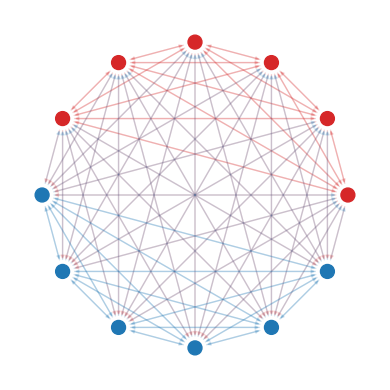

In [4]:
# Just looking at a single mesh point
npm = 12 # neurons per meshpoint
net = Network()
net.m = MeshPoint(npm)
net.build()

# Modify the positions a bit for the visualization
graph = net.graph()
pos = nx.circular_layout(graph)
node_index = {node: i for i, node in enumerate(graph.nodes())}
node_color = ['black' for node in graph.nodes()] # default
edge_index = {(source, target): i for i, (source, target) in enumerate(graph.edges())}
edge_color = ['gray' for edge in graph.edges()] # default

for i in range(npm//2):
    node_color[node_index[net.m.pos[i].name]] = 'tab:red'
    node_color[node_index[net.m.neg[i].name]] = 'tab:blue'

for source, target in graph.edges():
    if 'pos' in source:
        edge_color[edge_index[(source, target)]] = 'tab:red'
    elif 'neg' in source:
        edge_color[edge_index[(source, target)]] = 'tab:blue'

# Visualize
plt.figure(figsize=(4, 4))
nx.draw_networkx_nodes(graph, pos, node_size=100, node_color=node_color)
nx.draw_networkx_edges(graph, pos, edge_color=edge_color, alpha=0.2, width=1,arrowsize=5)

plt.axis('off')
plt.tight_layout()

In [5]:
# Now a container class for all the mesh points
class Mesh(Network):
    def __init__(self, mesh_points=None, mesh_edges=None, npm=8):
        super().__init__()
        self.mesh_points = mesh_points
        self.mesh_edges = mesh_edges
        self.npm = npm
        self.hnpm = npm//2

    def build(self):
        # Mesh Points
        # Potentially further parameterize mesh point with information
        self.mp = [MeshPoint(self.npm) for _ in range(len(self.mesh_points))]

        # Readout (one per mesh point)
        self.readout = NodeGroup(LIF(), len(self.mesh_points))

        # Readout Edges
        self.p_r = [EdgeGroup(self.mp[i].pos, self.readout, PSP(weight=1.0),
                              edges=[(j,i) for j in range(self.hnpm)])
                    for i in range(len(self.mesh_points))]
        self.n_r = [EdgeGroup(self.mp[i].neg, self.readout, PSP(weight=-1.0),
                              edges=[(j,i) for j in range(self.hnpm)])
                    for i in range(len(self.mesh_points))]
        
        # Mesh Edges (from the triangulation)
        self.p_m = []
        self.n_m = []
        for edge in mesh_edges:
            self.p_m.append(EdgeGroup(self.mp[edge[0]].pos, self.mp[edge[1]].all, PSP(weight=1.0),
                                      edges=[(i, j) for i, j in itertools.product(
                                          range(self.hnpm), range(self.npm))]))
            self.n_m.append(EdgeGroup(self.mp[edge[0]].neg, self.mp[edge[1]].all, PSP(weight=-1.0),
                                      edges=[(i, j) for i, j in itertools.product(
                                          range(self.hnpm), range(self.npm))]))
        
        return

In [6]:
# Mesh edges in terms of directional connectivity
# ignore connectivity into boundary points
# points within the mesh connect both directions
mesh_edges = []
for edge in ts.edges:
    if edge[0] < n_bdry and edge[1] < n_bdry:
        pass
    elif edge[0] < n_bdry:
        mesh_edges.append([edge[0],edge[1]])
    elif edge[1] < n_bdry:
        mesh_edges.append([edge[1],edge[0]])
    else:
        mesh_edges.append([edge[0],edge[1]])
        mesh_edges.append([edge[1],edge[0]])

In [7]:
# Now we look at constructing the full mesh
npm = 8 # neurons per meshpoint

# These are the coordinates of the points
mesh_points = [x for x in mesh.points]

net = Network()
net.m = Mesh(mesh_points, mesh_edges, npm)
net.build()

info: adding network m
info: building network m
info: adding list of networks m.mp
info: adding empty list m.p_m
info: adding empty list m.n_m
info: building network m.mp[0]
info: building network m.mp[1]
info: building network m.mp[2]
info: building network m.mp[3]
info: building network m.mp[4]
info: building network m.mp[5]
info: building network m.mp[6]
info: building network m.mp[7]
info: building network m.mp[8]
info: building network m.mp[9]
info: building network m.mp[10]
info: building network m.mp[11]
info: building network m.mp[12]
info: building network m.mp[13]
info: building network m.mp[14]
info: building network m.mp[15]
info: building network m.mp[16]
info: building network m.mp[17]
info: building network m.mp[18]
info: building network m.mp[19]
info: building network m.mp[20]
info: building network m.mp[21]
info: building network m.mp[22]
info: building network m.mp[23]
info: building network m.mp[24]
info: building network m.mp[25]
info: building network m.mp[26]
inf

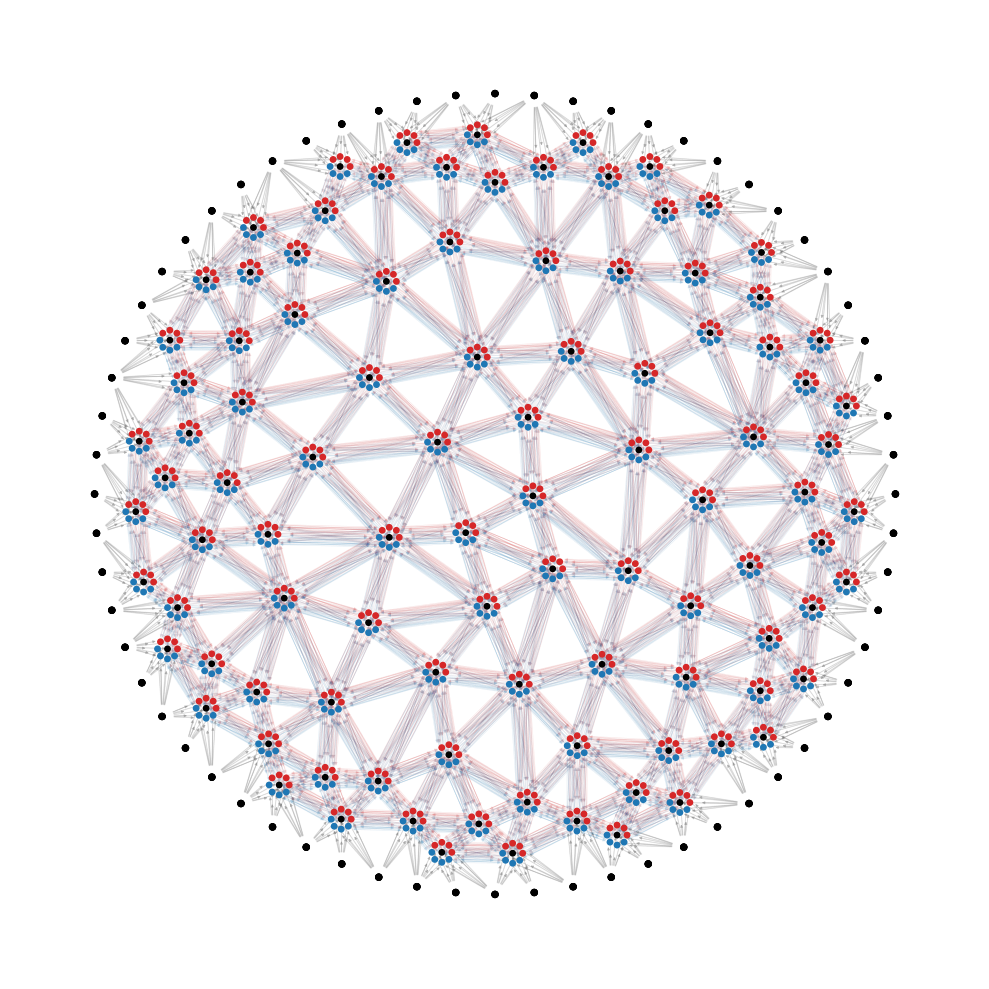

In [8]:
# Modify the positions a bit for the visualization
graph = net.graph()
pos = nx.circular_layout(graph)

# Give some slight offset for the interior mesh points
# Center the readout neurons at the mesh point
for i in range(len(mesh_points)):
    for j in range(npm):
        if i < n_bdry:
            pos[net.m.mp[i].all[j].name][0] = mesh_points[i][0] + 0.001*np.cos(2*np.pi*j/npm)
            pos[net.m.mp[i].all[j].name][1] = mesh_points[i][1] + 0.001*np.sin(2*np.pi*j/npm)
        else:
            pos[net.m.mp[i].all[j].name][0] = mesh_points[i][0] + 0.025*np.cos(2*np.pi*j/npm)
            pos[net.m.mp[i].all[j].name][1] = mesh_points[i][1] + 0.025*np.sin(2*np.pi*j/npm)
        pos[net.m.readout[i].name][0] = mesh_points[i][0]
        pos[net.m.readout[i].name][1] = mesh_points[i][1]

# Color the nodes and edges
node_index = {node: i for i, node in enumerate(graph.nodes())}
node_color = ['black' for node in graph.nodes()] # default
edge_index = {(source, target): i for i, (source, target) in enumerate(graph.edges())}
edge_color = ['gray' for edge in graph.edges()] # default
for source, target in graph.edges():
    match = re.search(r'\d+', source)
    mesh_index = int(match.group())
    if mesh_index < n_bdry:
        continue
    elif 'pos' in source:
        node_color[node_index[source]] = 'tab:red'
        edge_color[edge_index[(source, target)]] = 'tab:red'
    elif 'neg' in source:
        node_color[node_index[source]] = 'tab:blue'
        edge_color[edge_index[(source, target)]] = 'tab:blue'

# Visualize
plt.figure(figsize=(10, 10))
nx.draw_networkx_nodes(graph, pos, node_size=15, node_color=node_color)
nx.draw_networkx_edges(graph, pos, edge_color=edge_color, alpha=0.05, width=0.5, arrowsize=4)

plt.axis('off')
plt.tight_layout()